In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tifffile
import ipywidgets as W
from ipywidgets import interact, widgets, fixed

# Add src to path if running from notebooks folder
src_path = Path("../src").resolve()
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
    
from scene import generate_single_cell_3d
from render import N_POOLS
from tape import Tape
from plot import plot_surface_xyz_inline, plot_surface_xyz_html, ortho, tau_cmap
from parameter import P

%matplotlib inline

# 1) Synthetic cell generation

In [3]:
SEED = 64
N_CAND = 1500
SIZE = 201
TILE = 256
K = 20

# lowest SH degree. 0 = pure size (absorbed by the volume normalisation),
# 1 = shifts the centroid off the seed. 2 = lowest true shape mode.
L_MIN = 2          
# 4 is the ceiling of the hardcoded Cartesian forms
L     = 4          

# microns per LATERAL voxel
UM_PER_VOX = 0.325                 
# z voxels this many times COARSER than lateral
Z_RATIO    = 1.0                   
# (sz, sy, sx) = voxel SIZE per axis, in lateral units
SPACING    = (Z_RATIO, 1.0, 1.0)   
VOL        = (128, 128, 128)        

# 1) CELL GEOMETRY

RADIUS = P(4.0, 48.0, 0.5, 24.0, "radius", note="radius", 
           comment = "equivalent-sphere radius; volume is normalised to (4/3)pi R^3 whatever the roughness."
           )

ROUGH  = P(0.0, 0.50, 0.01, 0.25, "rough", note="rough",
           comment = "SD of log-radius: 0.25 ~ +-25% radial wobble. Orthogonal to radius and beta."
           )

BETA   = P(0.5, 4.0, 0.1, 1.9, "beta", note="beta",
           comment = "spectral tilt at FIXED total amplitude. Large -> a few fat lobes;\
small -> finer crenulation. Does NOT change how rough the cell is."
           )

ELONG  = P(0.3, 3.0, 0.05, 1.6, "elong", note="elong",
           comment = "volume-preserving aspect ratio. >1 prolate (rod), 1 = sphere, <1 oblate."
           )

# 2) NUCLEUS

NUC_FRAC   = P(0.10, 0.80, 0.01, 0.25, "nuc_frac",   note="nuc frac",
           comment = "nucleus:cell equivalent-RADIUS ratio -> volume ratio is nuc_frac**3."
           )

NUC_ROUGH  = P(0.0, 0.50, 0.01, 0.10, "nuc_rough",  note="nuc rough",
           comment = "nuclear log-radius SD (0.25 ~ +-25% radial wobble.) Orthogonal to radius and beta"
           )

# nuclear spectral tilt. Currently HARDCODED as beta+1.5 -- see caveat below.
NUC_BETA   = P(0.5, 6.0, 0.1, 3.2, "nuc_beta",    note="nuc beta",
           comment = "nuclear spectral tilt. Large -> a few fat lobes;\
small -> finer crenulation"
           )

NUC_CORR   = P(0.0, 1.0, 0.05, 0.40, "nuc_corr",   note="nuc corr",
           comment = "how much the nuclear outline mirrors the cell's"
           )

NUC_OFFSET = P(0.0, 1.0, 0.05, 0.90, "nuc_offset", note="nuc offset",
           comment = "nuclear displacement as a fraction of the free cytoplasmic room. \
0 puts the nucleus exactly on the tessellation seed -> trivially recoverable."
           )

RIM        = P(0.0, 8.0, 0.5, 1.5, "rim",          note="rim",
           comment = "minimum cytoplasm between nuclear and plasma membrane, in lateral voxels."
           )

# 3) ORIENTATION   (ZYZ: polar+azim aim the long axis, roll spins about it)

POLAR_DEG = P(0.0, 180.0, 5.0, 65.0, "polar_deg", note="polar")
AZIM_DEG  = P(0.0, 360.0, 5.0, 25.0, "azim_deg",  note="azim")
ROLL_DEG  = P(0.0, 360.0, 5.0,  0.0, "roll_deg",  note="roll")


# 4) DRAW THE TAPE

tape = Tape(seed=SEED, size=SIZE, K=K)
tape.draw(tile=TILE, n_cand=N_CAND, Pool=N_POOLS)
tape.draw3d(vol=VOL, n_cand=N_CAND, Pool=N_POOLS, l_min=L_MIN, L=L)

In [4]:
from dataclasses import dataclass

# Verify
FLUOROPHORES = {
    "DAPI": 0.461, "FITC": 0.519, "PE": 0.578, "APC": 0.660
}

# Optics: 
@dataclass(frozen=True)
class Optics:
    """Known Physical properties of the detector (Macsima) and the experiment."""
    um_per_px: float = 0.325 
    focal_um: float = 0.0
    
    # VERIFY
    na: float = 0.75 #or 0.45 
    wavelength_um: float = 0.530 
    
    n_immersion: float = 1.0
    
    @property
    def tan_theta(self):
        return float(np.tan(np.arcsin(np.clip(self.na / self.n_immersion, 0.0, 0.999))))

## 1.1) Cell shape gen

In [5]:
cell = generate_single_cell_3d(tape, i=0, size=VOL, radius=RADIUS.v, nuc_frac=NUC_FRAC.v, rough=ROUGH.v, elong=ELONG.v, beta=BETA.v,
          polar_deg=POLAR_DEG.v, azim_deg=AZIM_DEG.v, roll_deg=ROLL_DEG.v, rim=RIM.v, nuc_corr=NUC_CORR.v, nuc_offset=NUC_OFFSET.v, beta_nuc = NUC_BETA.v,
          rough_nuc = NUC_ROUGH.v)

(128, 128, 128) (128, 128, 128, 3)


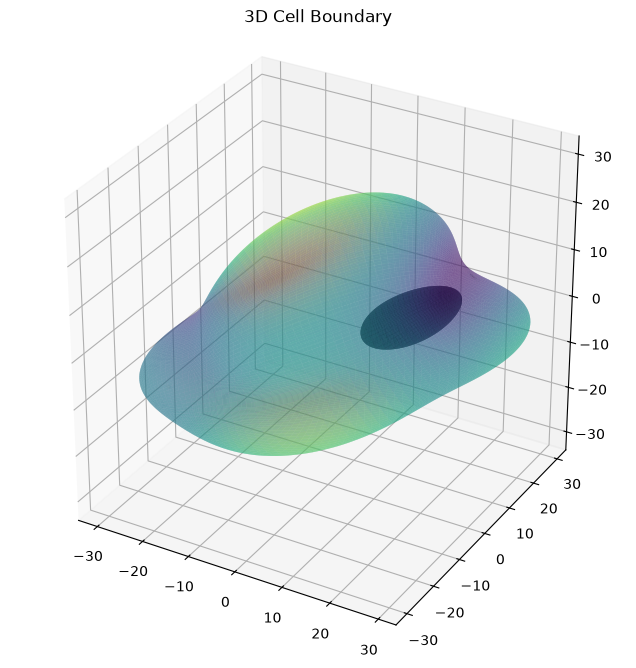

Saved interactive plot to interactive_cell_3d.html


In [6]:
fig = plot_surface_xyz_inline(cell = cell, elong = ELONG.v, 
                        polar_deg = POLAR_DEG.v, azim_deg = AZIM_DEG.v, roll_deg = ROLL_DEG.v)
fig = plot_surface_xyz_html(cell = cell, elong = ELONG.v, 
                        polar_deg = POLAR_DEG.v, azim_deg = AZIM_DEG.v, roll_deg = ROLL_DEG.v,
                        out_path = Path("../renders").resolve())

(64, 64, 64)


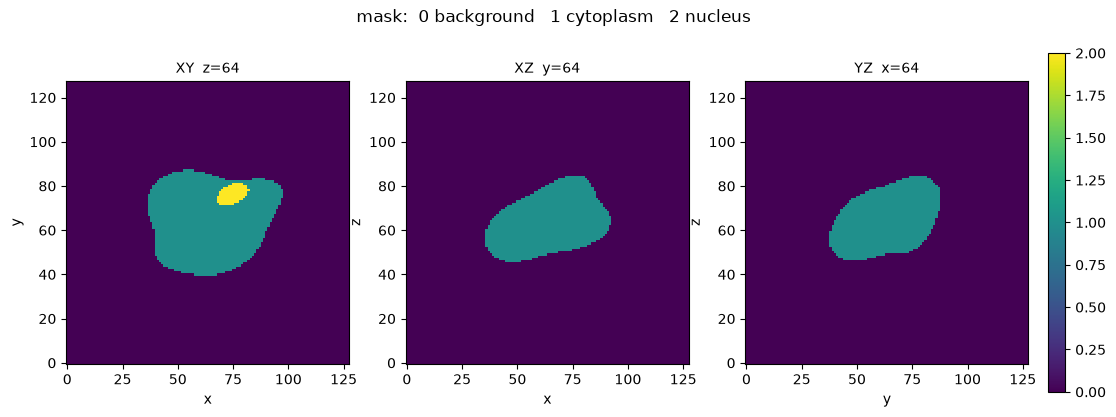

In [7]:
lab = cell["cell"].astype(np.int8) + cell["nuc"]        # 0 background, 1 cytoplasm, 2 nucleus
ortho(lab, cmap="viridis", title="mask:  0 background   1 cytoplasm   2 nucleus")
plt.show()

## 1.2) Cell Marker expression

### 1.2.2) Single Marker

(64, 64, 64)


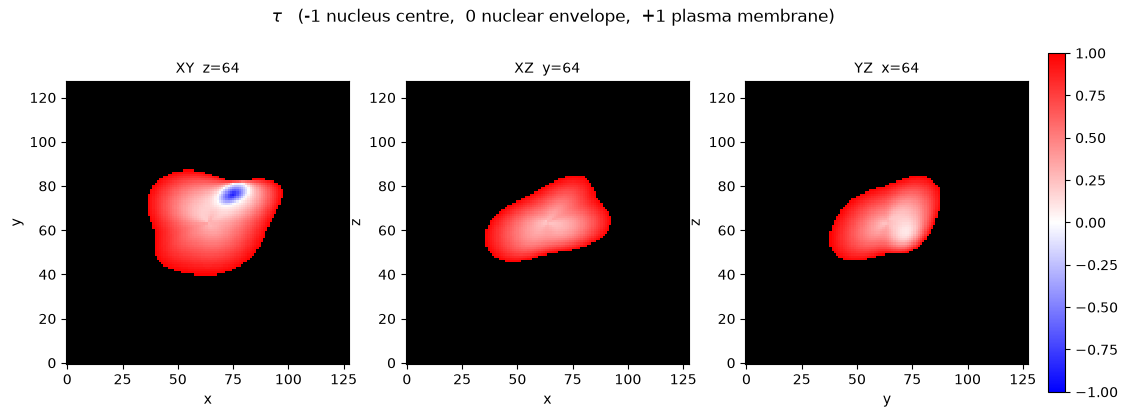

In [8]:
cm, vmin, vmax = tau_cmap(float(cell["tau"][cell["cell"]].max()))
ortho(cell["tau"], cmap=cm, vmin=vmin, vmax=vmax, mask=cell["cell"],
      title=r"$\tau$   (-1 nucleus centre,  0 nuclear envelope,  +1 plasma membrane)")
plt.show()